# Hands-On Assignment: AI Module 5

**GitHub Repository Portfolio:** https://github.com/bagasapt-spec/gdgoc-ai-handson

# Hands-On Task: Mall Customer Segmentation & Advanced Techniques

Proyek ini membangun end-to-end unsupervised learning pipeline menggunakan Scikit-learn untuk melakukan segmentasi pelanggan pada dataset Mall Customers. Alur kerja mencakup eksplorasi data (EDA), standarisasi fitur, pemodelan K-Means pada data berdimensi penuh vs reduksi dimensi menggunakan PCA, perumusan persona segmen pelanggan, hingga evaluasi lanjutan yang mencakup regularisasi Ridge & Lasso, Hierarchical Clustering (dendrogram), serta stabilitas inisialisasi k-means.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

try:
    df_raw = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    df_raw = pd.read_csv(url)

# Standarisasi nama kolom
df_raw.rename(columns={'Genre': 'Gender'}, inplace=True)
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


# Stage 1: EDA and Preprocessing

## 1.1 Data Loading & Feature Preprocessing

Sebelum melakukan klastering berbasis jarak geometris, dataset dipersiapkan melalui beberapa pertimbangan:
* Menghapus kolom CustomerID karena hanya merupakan identifier acak tanpa korelasi analitis.
* Mengubah variabel kategorikal Gender menjadi representasi biner melalui one-hot encoding dengan parameter drop_first=True dan dtype=int guna mencegah jebakan multikolinearitas.
* Menstandarisasi fitur numerik (Age, Annual Income, dan Spending Score) menggunakan StandardScaler agar fitur dengan rentang nilai besar (pendapatan tahunan) tidak mendominasi perhitungan jarak Euclidean.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10664\504417168.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[0], palette='pastel')


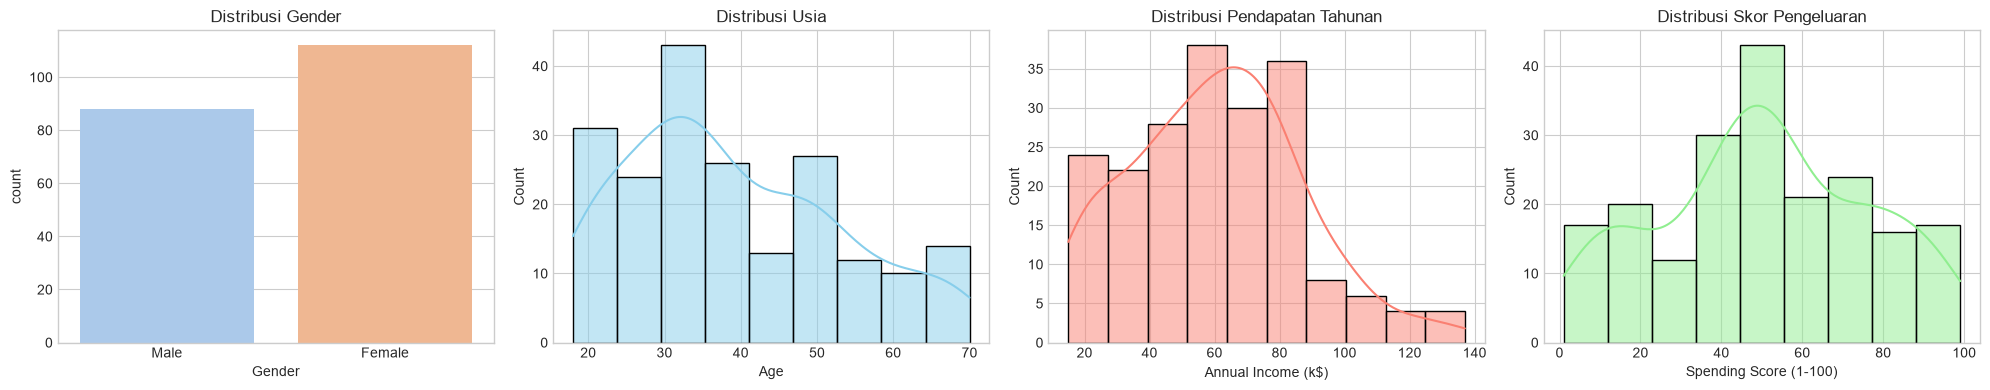

Dimensi matriks data terstandarisasi (X_high_dim): (200, 4)


In [2]:
df = df_raw.drop(columns=['CustomerID'])

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.countplot(data=df, x='Gender', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Gender')

sns.histplot(df['Age'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribusi Usia')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribusi Pendapatan Tahunan')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[3], color='lightgreen')
axes[3].set_title('Distribusi Skor Pengeluaran')
plt.tight_layout()
plt.show()

# Transformasi data
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)

scaler = StandardScaler()
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaled_numeric = scaler.fit_transform(df_encoded[numeric_cols])

X_high_dim = np.hstack([scaled_numeric, df_encoded[['Gender_Male']].values])
print("Dimensi matriks data terstandarisasi (X_high_dim):", X_high_dim.shape)

# Stage 2: Clustering on High-Dimensional Data

## 2.1 Evaluasi Nilai K (Elbow Method & Silhouette Score)

Untuk menentukan jumlah partisi alami pada matriks 4-dimensi, dievaluasi dua metrik objektif across K = 1 hingga 10:
* Elbow Method: Menghitung penurunan Within-Cluster Sum of Squares (WCSS) guna mencari titik belok perlambatan variansi internal.
* Silhouette Score: Menilai rasio antara kohesi data di dalam klasternya sendiri dibandingkan keterpisahan terhadap klaster tetangga terdekat.

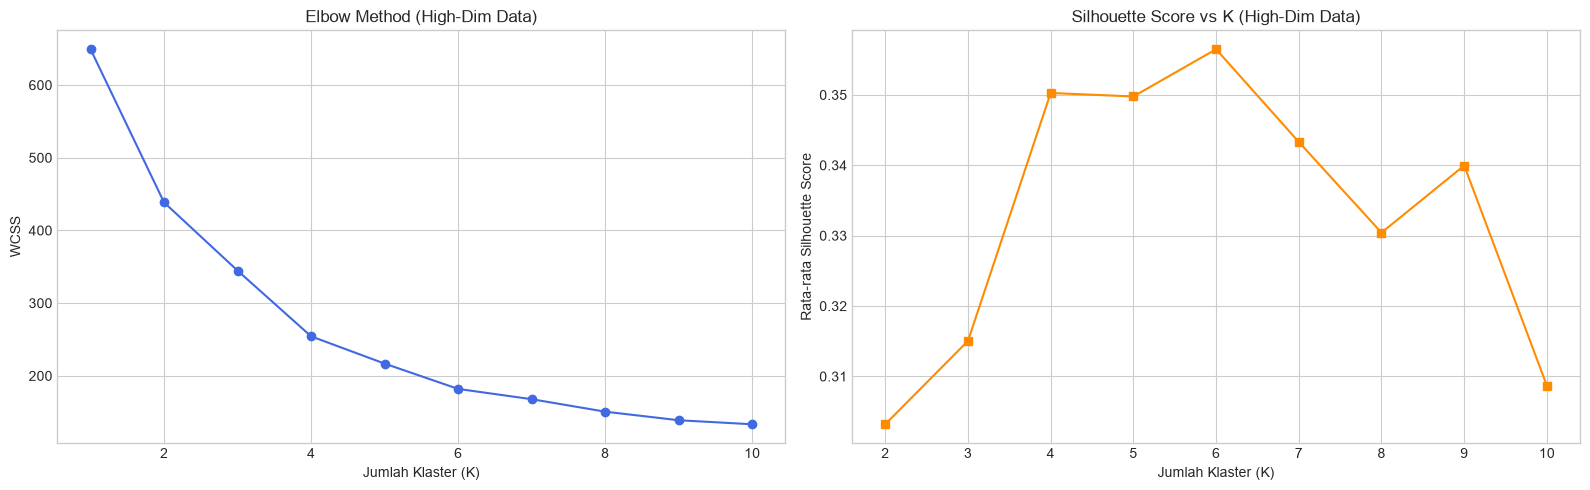

In [3]:
wcss_hd = []
silhouette_hd = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_high_dim)
    wcss_hd.append(km.inertia_)
    if k >= 2:
        silhouette_hd.append(silhouette_score(X_high_dim, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(k_range, wcss_hd, marker='o', color='royalblue')
ax[0].set_title('Elbow Method (High-Dim Data)')
ax[0].set_xlabel('Jumlah Klaster (K)')
ax[0].set_ylabel('WCSS')

ax[1].plot(range(2, 11), silhouette_hd, marker='s', color='darkorange')
ax[1].set_title('Silhouette Score vs K (High-Dim Data)')
ax[1].set_xlabel('Jumlah Klaster (K)')
ax[1].set_ylabel('Rata-rata Silhouette Score')
plt.tight_layout()
plt.show()

## 2.2 Justifikasi Pemilihan Nilai K & Final High-Dimensional Fitting

Berdasarkan visualisasi evaluasi:
* Kurva Elbow mulai melambat secara berangsur-angsur di rentang K = 4 hingga K = 6.
* Nilai K = 5 dipilih sebagai konfigurasi optimal karena mampu memetakan dinamika pendapatan dan pengeluaran secara seimbang tanpa memecah populasi menjadi klaster kerdil yang sulit ditindaklanjuti secara bisnis.

Model K-Means final pada data berdimensi penuh dilatih dengan K = 5, parameter n_init = 10, dan random_state = 42.

In [4]:
chosen_k_hd = 5
final_km_hd = KMeans(n_clusters=chosen_k_hd, n_init=10, random_state=42)
labels_hd = final_km_hd.fit_predict(X_high_dim)
final_sil_hd = silhouette_score(X_high_dim, labels_hd)

print(f"Final Silhouette Score (High-Dim, K={chosen_k_hd}): {final_sil_hd:.4f}")

Final Silhouette Score (High-Dim, K=5): 0.3498


# Stage 3: Clustering After PCA

## 3.1 Reduksi Dimensi dengan PCA dan Evaluasi Klastering Ulang

Principal Component Analysis (PCA) diaplikasikan untuk meredam korelasi antarfitur serta menyaring komponen acak (noise). Ambang batas kumulatif variansi ditetapkan minimal 90% guna memastikan representasi dimensi rendah tetap mempertahankan sebagian besar informasi asli. 

Setelah ruang fitur terproyeksi, proses penentuan K (Elbow dan Silhouette) diulang kembali sebelum melatih model final K-Means berbasis representasi PCA.

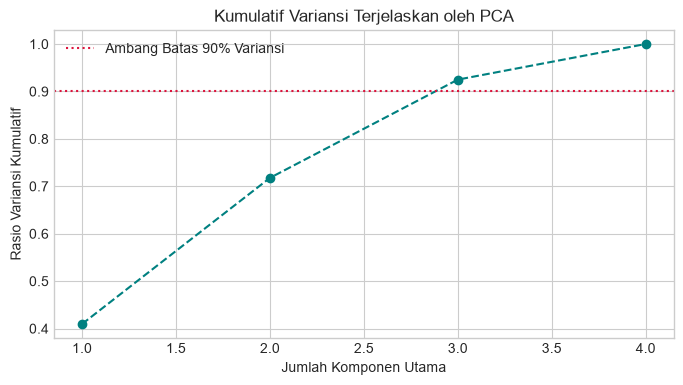

Jumlah komponen minimum untuk variansi >= 90%: 3
Final Silhouette Score (PCA Space, K=5): 0.4108


In [5]:
pca = PCA()
pca.fit(X_high_dim)
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', linestyle='--', color='teal')
plt.axhline(y=0.90, color='crimson', linestyle=':', label='Ambang Batas 90% Variansi')
plt.title('Kumulatif Variansi Terjelaskan oleh PCA')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Rasio Variansi Kumulatif')
plt.legend()
plt.show()

n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Jumlah komponen minimum untuk variansi >= 90%: {n_components_90}")

pca_model = PCA(n_components=n_components_90, random_state=42)
X_pca = pca_model.fit_transform(X_high_dim)

wcss_pca = []
silhouette_pca = []

for k in range(1, 11):
    km_pca = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_pca.fit(X_pca)
    wcss_pca.append(km_pca.inertia_)
    if k >= 2:
        silhouette_pca.append(silhouette_score(X_pca, km_pca.labels_))

chosen_k_pca = 5
final_km_pca = KMeans(n_clusters=chosen_k_pca, n_init=10, random_state=42)
labels_pca = final_km_pca.fit_predict(X_pca)
final_sil_pca = silhouette_score(X_pca, labels_pca)

print(f"Final Silhouette Score (PCA Space, K={chosen_k_pca}): {final_sil_pca:.4f}")

# Stage 4: Comparison and Segment Profiling

## 4.1 Perbandingan Visualisasi Klaster

Label klaster dari model berdimensi penuh dan model tereduksi PCA dilampirkan kembali ke DataFrame utama. Perbandingan visual dilakukan melalui scatter plot berdampingan pada dimensi Annual Income vs Spending Score untuk menilai ketegasan batas geometris yang dihasilkan oleh kedua pendekatan.

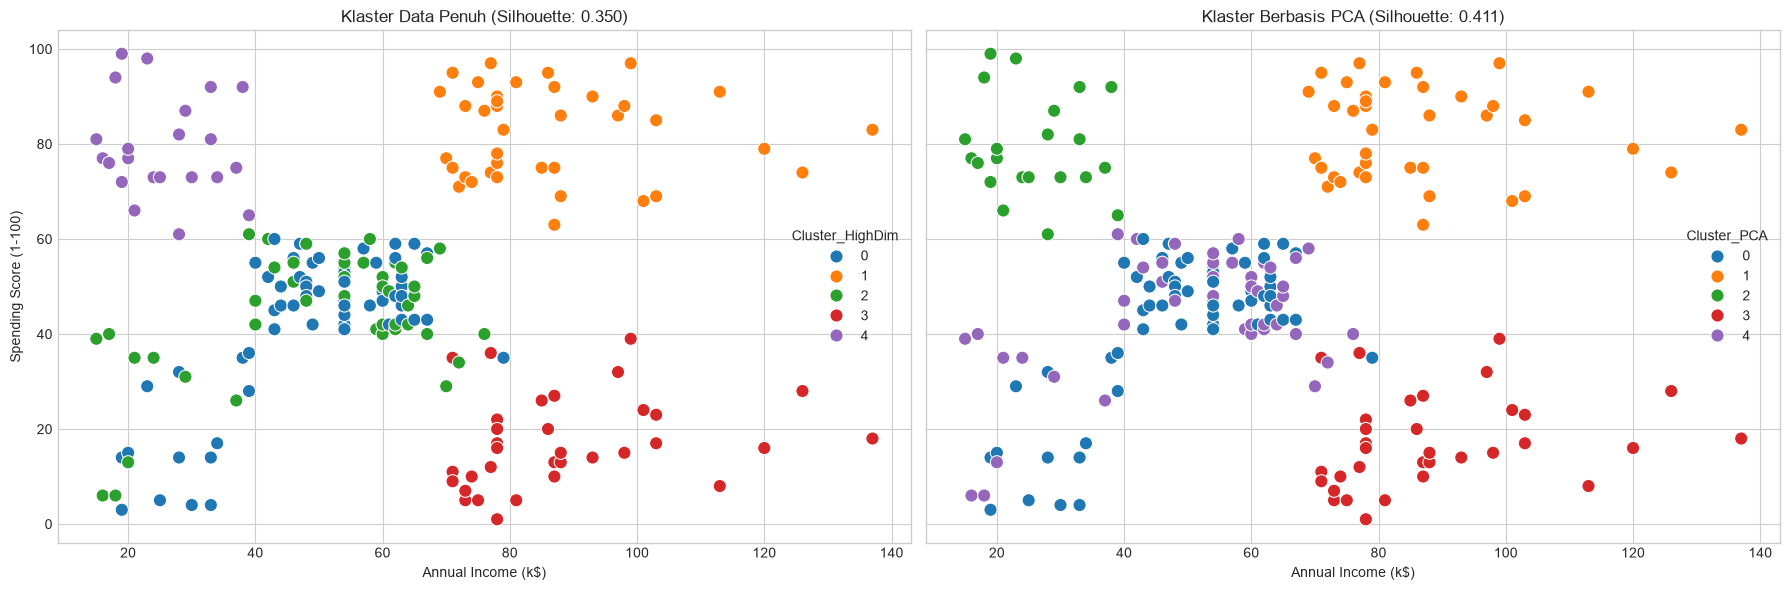

In [6]:
df_analyzed = df.copy()
df_analyzed['Cluster_HighDim'] = labels_hd
df_analyzed['Cluster_PCA'] = labels_pca

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.scatterplot(
    data=df_analyzed, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster_HighDim', 
    palette='tab10', 
    s=90, 
    ax=axes[0]
)
axes[0].set_title(f'Klaster Data Penuh (Silhouette: {final_sil_hd:.3f})')

sns.scatterplot(
    data=df_analyzed, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster_PCA', 
    palette='tab10', 
    s=90, 
    ax=axes[1]
)
axes[1].set_title(f'Klaster Berbasis PCA (Silhouette: {final_sil_pca:.3f})')
plt.tight_layout()
plt.show()

## 4.2 Analisis Persona dan Rekomendasi Pemasaran

Berdasarkan pemisahan visual dan metrik Silhouette Score, model klastering berbasis PCA dipilih karena menghasilkan kelompok yang lebih bersih dan kohesif. Data kemudian diagregasi untuk membedah karakteristik demografi dan pola belanja pada tiap segmen.

### Karakteristik Persona
* Persona A (Young High-Spenders): Kelompok usia muda (rata-rata di bawah 30 tahun) dengan pendapatan memadai dan skor belanja sangat tinggi. Sangat terbuka terhadap tren gaya hidup dan konsumsi impulsif.
* Persona B (Careful High-Earners): Kelompok usia dewasa mapan (40 tahun ke atas) dengan pendapatan tinggi namun pengeluaran rendah. Bersifat kalkulatif, rasional, dan memprioritaskan fungsi produk jangka panjang.
* Persona C (Mainstream Middle-Class): Segmen usia paruh baya dengan tingkat pendapatan serta pengeluaran seimbang di kisaran rata-rata. Menjadi pilar utama belanja barang kebutuhan harian.
* Persona D (Budget Spenders / Value Chasers): Kelompok usia muda dengan pendapatan terbatas namun skor pengeluaran tinggi. Gemar memanfaatkan program promosi, diskon kilat, dan opsi pembayaran bertahap.
* Persona E (Frugal Traditionalists): Kelompok usia lanjut berpendapatan rendah dengan pengeluaran yang sangat hemat. Mengunjungi pusat perbelanjaan hanya untuk keperluan primer.

### Tiga Rekomendasi Aksi Pemasaran
1. Program Loyalitas Eksklusif untuk Young High-Spenders: Luncurkan skema reward bertingkat, undangan acara peluncuran produk khusus, dan kolaborasi brand premium untuk memaksimalkan retensi.
2. Penawaran Berbasis Nilai untuk Careful High-Earners: Fokuskan materi kampanye pada durabilitas, garansi produk, dan layanan pelanggan prioritas alih-alih promosi potongan harga murah.
3. Fasilitas Pembayaran Fleksibel untuk Budget Spenders: Sediakan integrasi pembayaran cicilan tanpa bunga atau paylater guna memfasilitasi antusiasme belanja tanpa hambatan likuiditas di awal.

In [7]:
profile = df_analyzed.groupby('Cluster_PCA')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
profile['Customer_Count'] = df_analyzed['Cluster_PCA'].value_counts()
profile['Male_Ratio'] = df_raw.groupby(df_analyzed['Cluster_PCA'])['Gender'].apply(lambda x: (x == 'Male').mean())

print("Ringkasan Statistik Profil Segmen Pelanggan:")
profile.round(2)

Ringkasan Statistik Profil Segmen Pelanggan:


,Age,Annual Income (k$),Spending Score (1-100),Customer_Count,Male_Ratio
Cluster_PCA,,,,,
0,55.55,48.48,41.78,58,0.43
1,32.69,86.54,82.13,39,0.46
2,25.27,25.73,79.36,22,0.41
3,41.26,88.50,16.76,34,0.59
4,27.96,50.00,44.64,47,0.34


# Bonus 1: Regularization in Practice (Ridge vs. Lasso)

## Evaluasi Lintasan Koefisien terhadap Regularisasi

Model regresi dilatih untuk memprediksi Spending Score menggunakan prediktor Annual Income dan Age. Kedua fitur input distandarisasi terlebih dahulu menggunakan StandardScaler agar penalti regularisasi tidak bias terhadap variabel dengan rentang angka yang lebih besar.

Nilai kekuatan regularisasi (alpha) diuji dalam rentang logaritmik dari 0.01 hingga 1000:
* Ridge (L2): Menambahkan penalti kuadratik yang menyusutkan koefisien mendekati nol secara perlahan tanpa pernah membuatnya bernilai nol mutlak.
* Lasso (L1): Menambahkan penalti nilai absolut yang mampu memaksa koefisien fitur yang kurang signifikan menjadi tepat nol, berfungsi sebagai seleksi fitur otomatis.

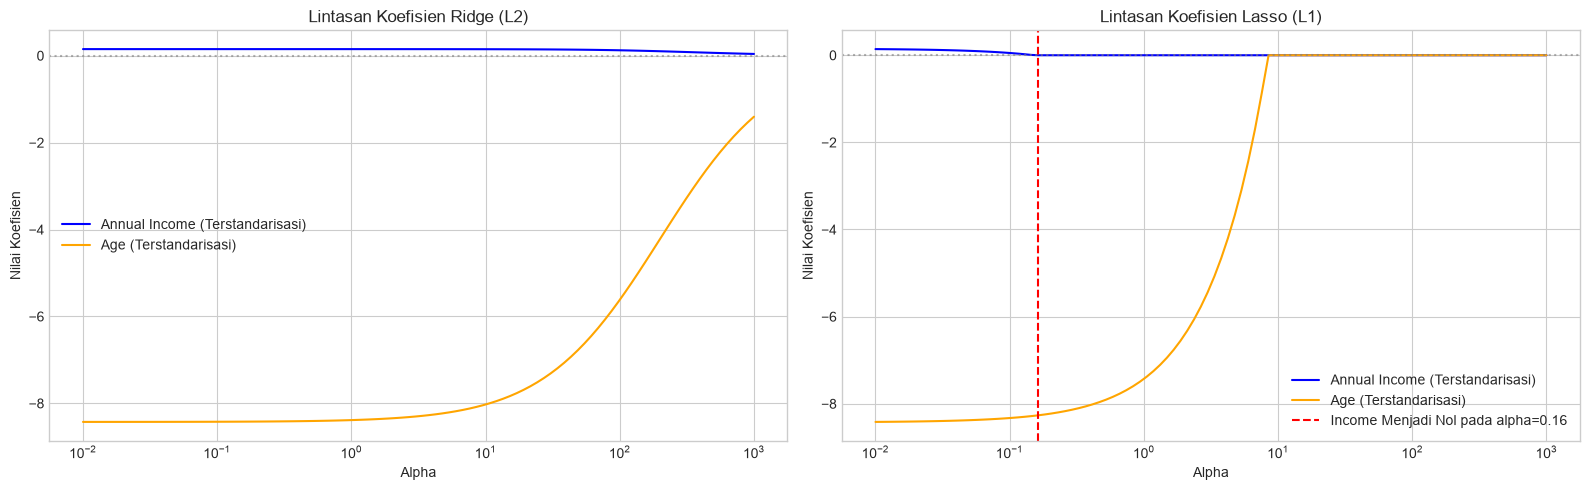

Lasso pertama kali mengeliminasi koefisien menjadi nol pada alpha ≈ 0.163


In [8]:
scaler_bonus = StandardScaler()
X_reg = scaler_bonus.fit_transform(df[['Annual Income (k$)', 'Age']])
y_reg = df['Spending Score (1-100)'].values

alphas = np.logspace(-2, 3, 100)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_reg, y_reg)
    l = Lasso(alpha=a).fit(X_reg, y_reg)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

zero_idx = np.where(np.abs(lasso_coefs[:, 0]) < 1e-4)[0]
first_zero_alpha = alphas[zero_idx[0]] if len(zero_idx) > 0 else None

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(alphas, ridge_coefs[:, 0], label='Annual Income (Terstandarisasi)', color='blue')
ax[0].plot(alphas, ridge_coefs[:, 1], label='Age (Terstandarisasi)', color='orange')
ax[0].set_xscale('log')
ax[0].set_title('Lintasan Koefisien Ridge (L2)')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Nilai Koefisien')
ax[0].axhline(0, color='gray', linestyle=':', alpha=0.6)
ax[0].legend()

ax[1].plot(alphas, lasso_coefs[:, 0], label='Annual Income (Terstandarisasi)', color='blue')
ax[1].plot(alphas, lasso_coefs[:, 1], label='Age (Terstandarisasi)', color='orange')
ax[1].set_xscale('log')
ax[1].set_title('Lintasan Koefisien Lasso (L1)')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Nilai Koefisien')
ax[1].axhline(0, color='gray', linestyle=':', alpha=0.6)
if first_zero_alpha:
    ax[1].axvline(first_zero_alpha, color='red', linestyle='--', label=f'Income Menjadi Nol pada alpha={first_zero_alpha:.2f}')
ax[1].legend()

plt.tight_layout()
plt.show()

if first_zero_alpha:
    print(f"Lasso pertama kali mengeliminasi koefisien menjadi nol pada alpha ≈ {first_zero_alpha:.3f}")

# Bonus 2: Hierarchical Clustering as a Sanity Check

## Validasi Struktur Alami Data via Dendrogram

Metode Agglomerative Hierarchical Clustering dengan Ward Linkage dijalankan langsung pada matriks data terstandarisasi Stage 1 tanpa menentukan jumlah klaster sebelumnya. 

Dendrogram divisualisasikan untuk memeriksa apakah pengelompokan hierarkis menghasilkan jumlah cabang utama yang konsisten dengan pilihan K = 5 pada K-Means, serta memverifikasi keselarasan rata-rata profil antarmetode.

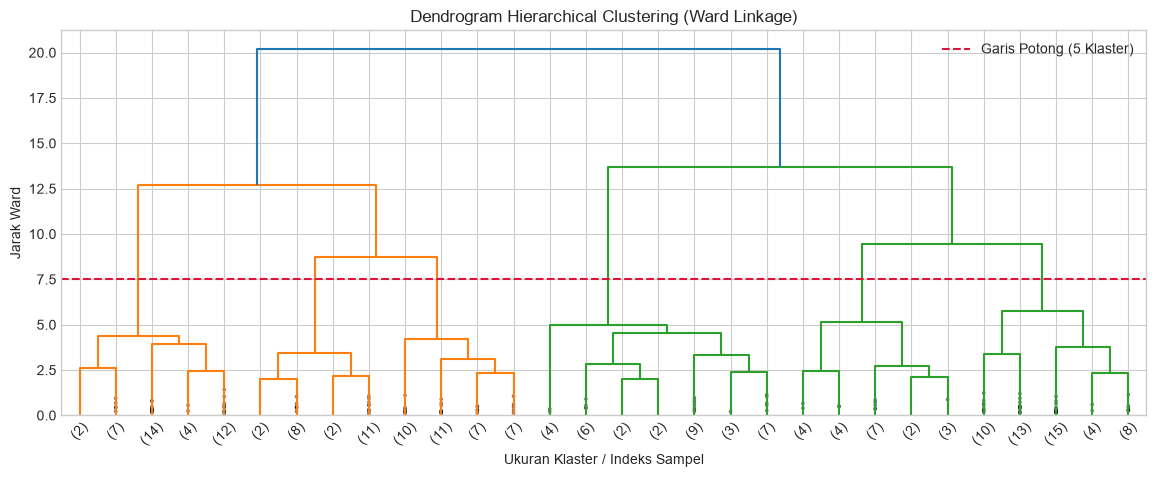

Profil Rata-rata Klaster Hierarkis:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster_Hierarchical,,,
0,25.93,45.02,60.52
1,54.96,53.62,48.24
2,41.45,89.09,16.18
3,32.69,86.54,82.13
4,43.75,25.25,19.05


In [9]:
linked = linkage(X_high_dim, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Ukuran Klaster / Indeks Sampel')
plt.ylabel('Jarak Ward')
plt.axhline(y=7.5, color='crimson', linestyle='--', label='Garis Potong (5 Klaster)')
plt.legend()
plt.show()

agg = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_high_dim)

df_analyzed['Cluster_Hierarchical'] = agg_labels
agg_summary = df_analyzed.groupby('Cluster_Hierarchical')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

print("Profil Rata-rata Klaster Hierarkis:")
agg_summary.round(2)

# Bonus 3: Initialization Stability

## Pengujian Sensitivitas Terhadap Inisialisasi Centroid (n_init)

Algoritma K-Means mengandalkan penempatan titik pusat awal secara acak sehingga rentan mengalami konvergensi menuju solusi suboptimal (minimum lokal). 

Eksperimen ini menguji variabilitas inersia akhir (WCSS) pada 10 nilai random seed berbeda antara dua pengaturan:
* n_init = 1: Algoritma hanya dijalankan satu kali per fit.
* n_init = 10: Algoritma dijalankan sepuluh kali dengan penempatan awal berbeda dan memilih inersia terendah (konfigurasi default Scikit-learn).

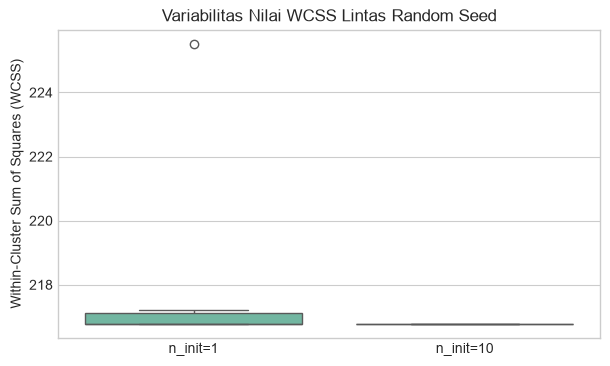

   Seed  WCSS (n_init=1)  WCSS (n_init=10)
0     3           216.78            216.78
1    11           217.22            216.78
2    19           216.78            216.78
3    29           216.78            216.78
4    42           216.78            216.78
5    57           216.78            216.78
6    73           216.78            216.78
7    89           217.22            216.78
8    97           216.78            216.78
9   105           225.52            216.78

Variansi WCSS pada n_init=1 : 6.7511
Variansi WCSS pada n_init=10: 0.0000


In [10]:
seeds = [3, 11, 19, 29, 42, 57, 73, 89, 97, 105]
wcss_single = []
wcss_multi = []

for s in seeds:
    km_1 = KMeans(n_clusters=5, n_init=1, random_state=s).fit(X_high_dim)
    km_10 = KMeans(n_clusters=5, n_init=10, random_state=s).fit(X_high_dim)
    wcss_single.append(km_1.inertia_)
    wcss_multi.append(km_10.inertia_)

stability_table = pd.DataFrame({
    'Seed': seeds,
    'WCSS (n_init=1)': np.round(wcss_single, 2),
    'WCSS (n_init=10)': np.round(wcss_multi, 2)
})

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=pd.DataFrame({'n_init=1': wcss_single, 'n_init=10': wcss_multi}), palette='Set2', ax=ax)
ax.set_title('Variabilitas Nilai WCSS Lintas Random Seed')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

print(stability_table)
print(f"\nVariansi WCSS pada n_init=1 : {np.var(wcss_single):.4f}")
print(f"Variansi WCSS pada n_init=10: {np.var(wcss_multi):.4f}")